# 지경학적 분절화는 서비스 교역에서도 일어나는가 — 재현 노트북

`paper.md`의 그림 셋을 다시 그리고, 본문이 인용한 수치를 하나씩 대조한다. 원 계산은 연구 3의
노트북(`research/03-fragmentation-extended/reproduce.ipynb`)이 수행하며, 이 노트북은 그 결과물인
`out/`의 CSV와 `out/stats.json`만 읽는다. 따라서 DuckDB 없이도 실행된다.

차례: §0 설정 · §1 그림 1 · §2 그림 2 · §3 그림 3 · §4 본문 수치 검증

## §0. 설정

연구 3의 산출물 폴더를 찾고 그림 표준을 맞춘다. 표준은 연구 3와 같다. 흑백, 300dpi,
Malgun Gothic, 위·오른쪽 축선 제거, 격자 0.87이다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from matplotlib.ticker import MultipleLocator

HERE = Path.cwd()
if not (HERE / "paper.md").exists() and (HERE / "research" / "02-fragmentation").exists():
    HERE = HERE / "research" / "02-fragmentation"
assert (HERE / "paper.md").exists(), f"연구 폴더에서 실행한다 (지금: {HERE})"
SRC = HERE.parent / "03-fragmentation-extended" / "out"
assert SRC.exists(), f"연구 3의 산출물이 없다: {SRC}"
IMG = HERE / "img"
IMG.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "Malgun Gothic", "axes.unicode_minus": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "0.87", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
})


def year_axis(ax, step=2):
    ax.xaxis.set_major_locator(MultipleLocator(step))
    ax.xaxis.set_major_formatter(lambda v, pos: f"{int(v)}")


def mark_periods(ax):
    ax.axvspan(2019.5, 2021.5, color="0.93", lw=0)
    for x in (2018, 2022):
        ax.axvline(x, color="0.55", lw=0.8, ls=":")


S = json.load(open(SRC / "stats.json", encoding="utf-8"))
ann = pd.read_csv(SRC / "annual_D1.csv", index_col=0)
cat = pd.read_csv(SRC / "annual_category_D1.csv", index_col=0)
net = pd.read_csv(SRC / "network_ari.csv", index_col=0)
print(HERE, "|", SRC)

C:\Work\Projects\Services\research\02-fragmentation | C:\Work\Projects\Services\research\03-fragmentation-extended\out


## §1. 그림 1 — 블록 간 교역 비중의 추이

기준안 블록 구분에서 상품과 서비스의 연도별 블록 간 교역 비중이다. 연구 3의 그림 1이 두 칸에
세 계열을 그린 것과 달리, 이 논문은 한 칸에 두 기준 계열만 그린다.

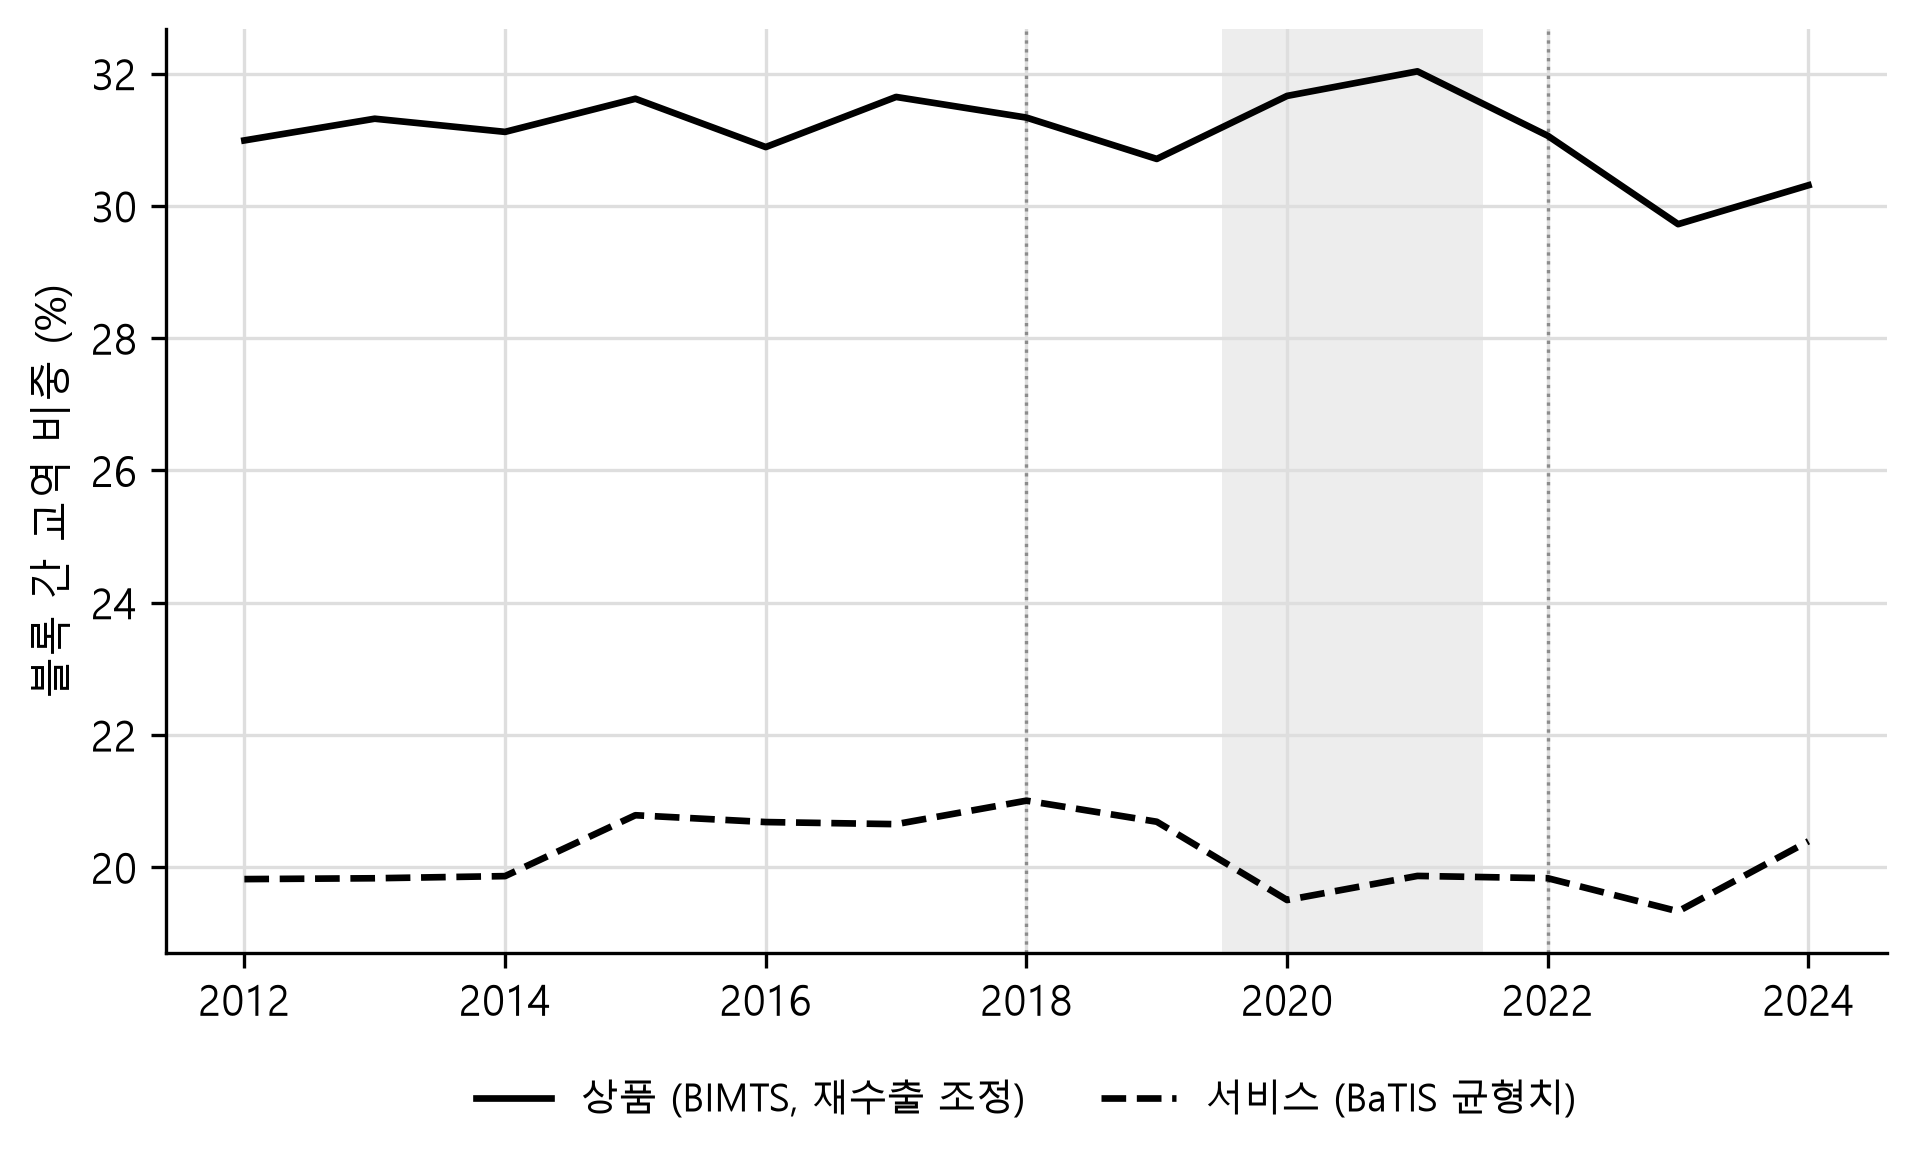

In [2]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
mark_periods(ax)
ax.plot(ann.index, ann.goods_rx, color="black", lw=1.6, label="상품 (BIMTS, 재수출 조정)")
ax.plot(ann.index, ann.svc_bal, color="black", lw=1.6, ls="--", label="서비스 (BaTIS 균형치)")
ax.set_ylabel("블록 간 교역 비중 (%)")
ax.legend(ncol=2, loc="upper center", fontsize=9, bbox_to_anchor=(0.5, -0.1))
year_axis(ax)
fig.savefig(IMG / "fig1_cross_share.png")
plt.close(fig)
display(Image(IMG / "fig1_cross_share.png", width=740))

## §2. 그림 2 — 서비스 범주별 블록 간 교역 비중

다섯 범주 가운데 본문이 다루는 넷을 그리고, 비교를 위해 상품의 블록 간 비중을 옅은 점선으로
함께 둔다. 연구 3의 그림 2와 같은 구성이다.

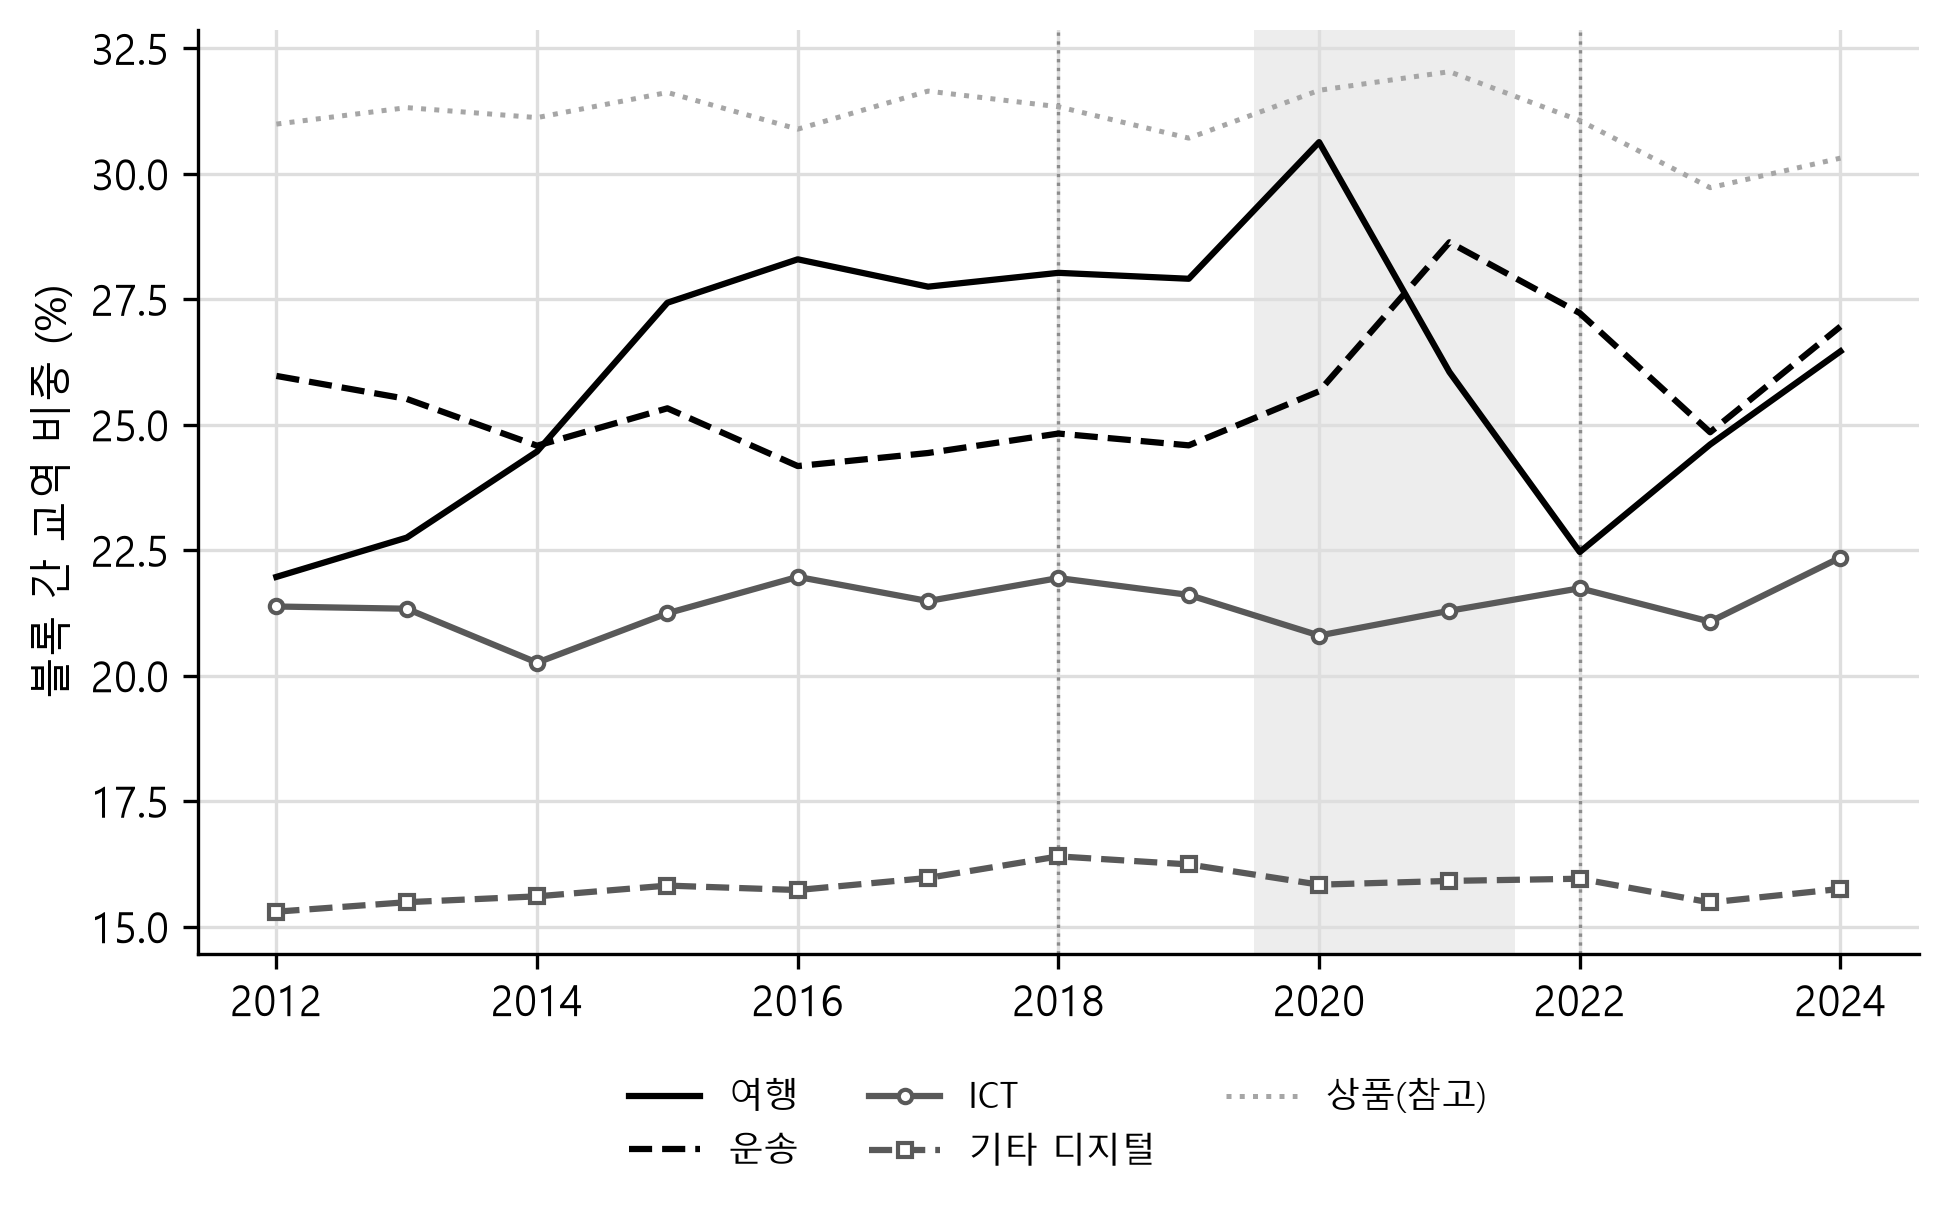

In [3]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
mark_periods(ax)
style = {"여행": ("black", "-", None), "운송": ("black", "--", None), "ICT": ("0.35", "-", "o"),
         "기타 디지털": ("0.35", "--", "s")}
for g, (c, ls, mk) in style.items():
    ax.plot(cat.index, cat[g], color=c, ls=ls, lw=1.5, marker=mk, ms=3.2, mfc="white", mec=c, label=g)
ax.plot(ann.index, ann.goods_rx, color="0.65", lw=1.2, ls=":", label="상품(참고)")
ax.set_ylabel("블록 간 교역 비중 (%)")
ax.legend(ncol=3, loc="upper center", fontsize=8.5, bbox_to_anchor=(0.5, -0.1))
year_axis(ax)
fig.savefig(IMG / "fig2_categories.png")
plt.close(fig)
display(Image(IMG / "fig2_categories.png", width=740))

## §3. 그림 3 — 교역망의 블록 모듈러리티

블록 구분을 교역망에 그대로 적용했을 때의 가중 모듈러리티다. 연구 3의 그림 3은 조정 랜드 지수를
함께 실었으나, 그 지표는 군집 수에 좌우되어 구조 변화의 증거로 쓰지 않으므로 여기서는 뺐다.

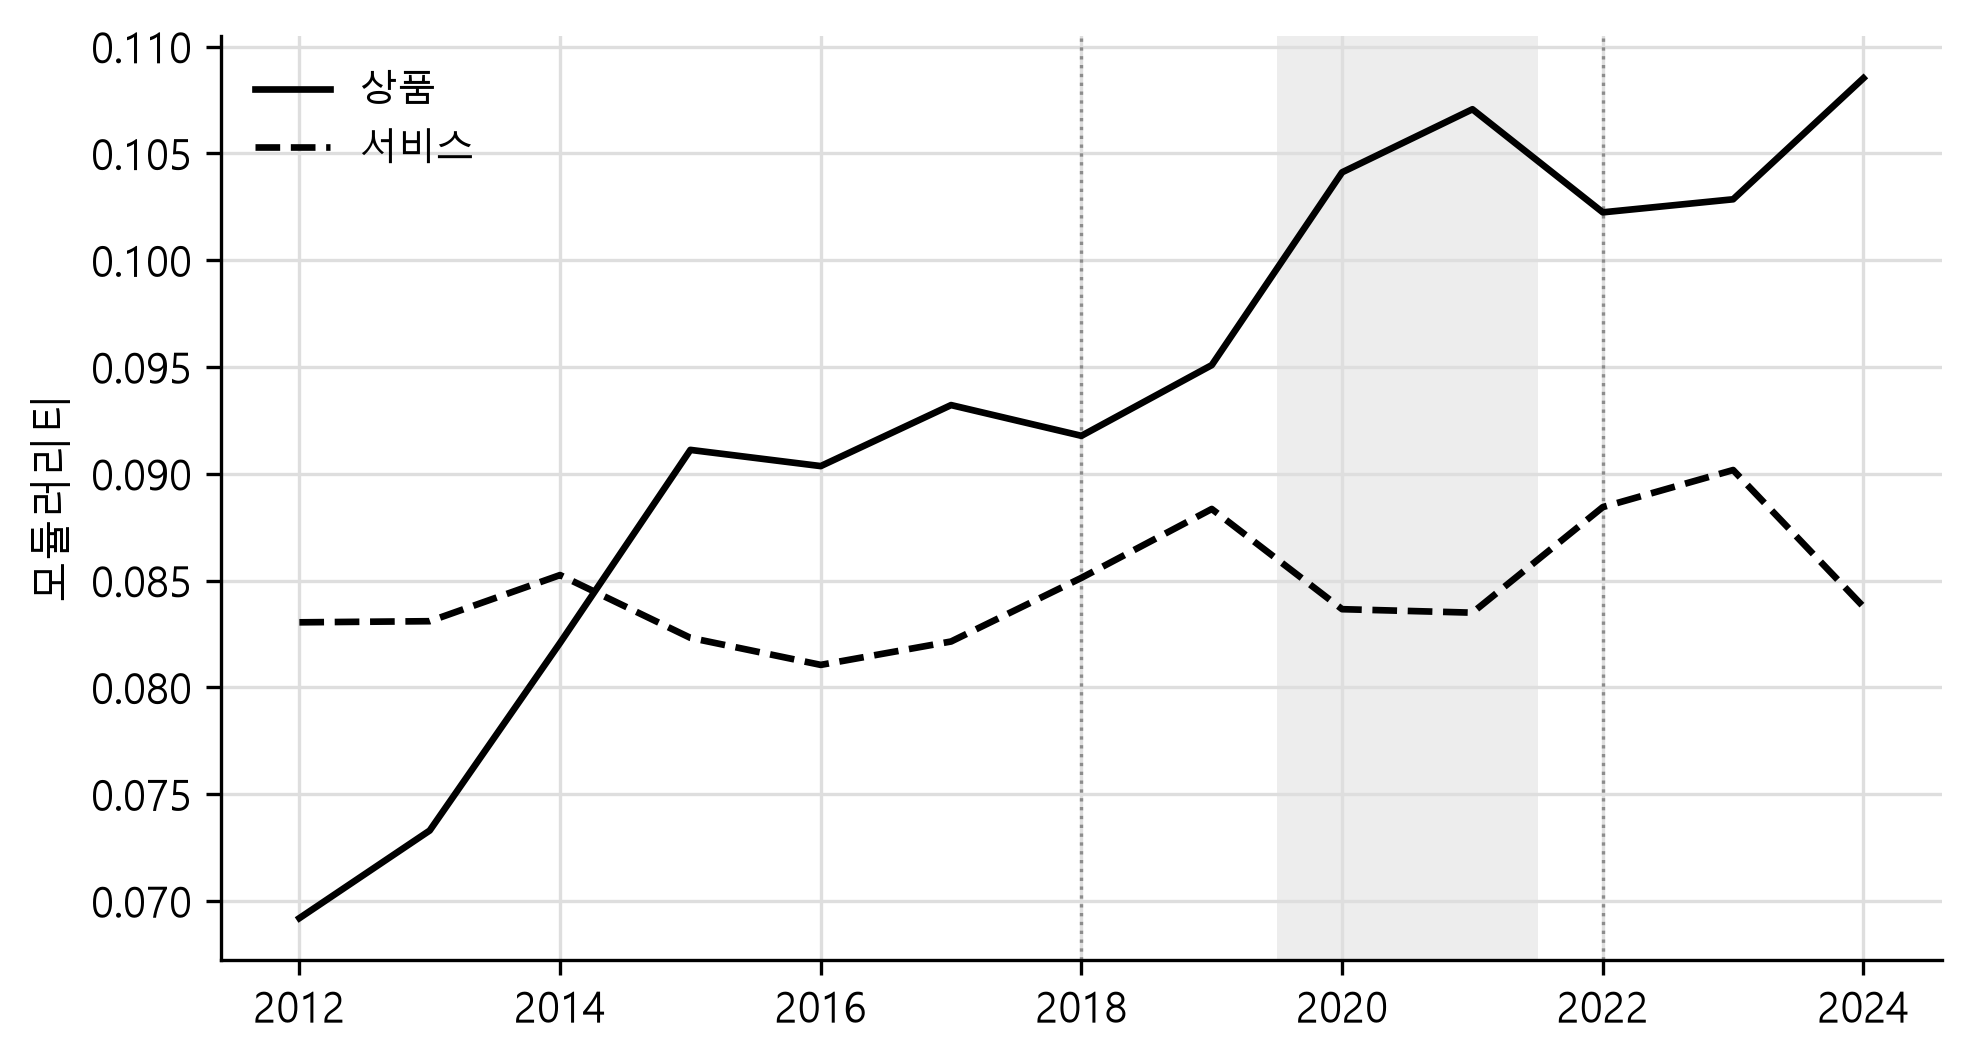

In [4]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
mark_periods(ax)
ax.plot(net.index, net.goods_q_d1, color="black", lw=1.6, label="상품")
ax.plot(net.index, net.svc_q_d1, color="black", lw=1.6, ls="--", label="서비스")
ax.set_ylabel("모듈러리티")
ax.legend(loc="upper left", fontsize=9)
year_axis(ax)
fig.savefig(IMG / "fig3_modularity.png")
plt.close(fig)
display(Image(IMG / "fig3_modularity.png", width=740))

## §4. 본문 수치 검증

`paper.md`가 인용한 값을 연구 3의 `out/stats.json`과 대조한다. 본문을 고치면 이 절도 함께 고친다.
어긋나면 `AssertionError`로 멈춘다.

In [5]:
def chk(name, got, want, tol=0.006):
    ok = got is not None and abs(got - want) <= tol
    print(("OK  " if ok else "FAIL") + f" {name}: 계산 {got} / 본문 {want}")
    assert ok, f"{name}: 계산 {got} != 본문 {want}"


M, P, B = S["main"], S["panel"], S["blocs"]
svc, gds = M["D1|svc_bal"], M["D1|goods_rx"]

# II.1 표본
chk("표본 흐름 수", P["n_pairs"], 9196, 0)
chk("표본 경제 수", P["n_economies"], 201, 0)
chk("서비스 포괄 2019", P["svc_cover_2019"], 82.3, 0.05)
chk("서비스 포괄 2023", P["svc_cover_2023"], 83.8, 0.05)
chk("상품 포괄 2019", P["goods_cover_2019"], 75.8, 0.05)
chk("상품 포괄 2023", P["goods_cover_2023"], 74.1, 0.05)
assert P["usa_chn_in"]
RR = S["report_rate"]
chk("미국 상대별 보고 사전", RR["USA_pre"], 35.5, 0.05)
chk("미국 상대별 보고 사후", RR["USA_post"], 94.0, 0.05)
chk("러시아 상대별 보고 사전", RR["RUS_pre"], 96.5, 0.05)
chk("러시아 상대별 보고 사후", RR["RUS_post"], 0.0, 0.05)
RC = P["rep_complete"]
chk("보고 완결도 2012", RC["2012"], 91.4, 0.05)
chk("보고 완결도 2013", RC["2013"], 95.5, 0.05)
chk("보고 완결도 2024", RC["2024"], 72.9, 0.05)
assert min(RC[str(y)] for y in range(2014, 2024)) >= 99.0

# II.2 블록
chk("미국 측 블록", B["D1"]["US"], 58, 0)
chk("중국 측 블록", B["D1"]["CN"], 51, 0)
chk("비동맹", B["D1"]["NON"], 95, 0)

# III.1 그림 1 인용
A = S["annual_D1"]
chk("서비스 2017", A["2017"]["svc_bal"], 20.65)
chk("서비스 2018", A["2018"]["svc_bal"], 21.01)
chk("서비스 2020", A["2020"]["svc_bal"], 19.50)
chk("서비스 2023", A["2023"]["svc_bal"], 19.33)
chk("서비스 2024", A["2024"]["svc_bal"], 20.39)
chk("상품 2019", A["2019"]["goods_rx"], 30.71)
chk("상품 2021", A["2021"]["goods_rx"], 32.03)
chk("상품 2023", A["2023"]["goods_rx"], 29.72)
chk("상품 2024", A["2024"]["goods_rx"], 30.31)

# III.2 표 1
chk("서비스 사전 수준", svc["S_pre"], 20.70); chk("상품 사전 수준", gds["S_pre"], 31.39)
chk("서비스 사전 추세", svc["d_pretrend"], 0.86); chk("상품 사전 추세", gds["d_pretrend"], 0.25)
chk("서비스 무역분쟁", svc["d_war"], 0.14); chk("상품 무역분쟁", gds["d_war"], -0.37)
chk("서비스 사후", svc["d_post"], -0.84); chk("상품 사후", gds["d_post"], -1.02)
chk("서비스 로그 오즈", svc["dlogodds_post"], -0.052, 0.0006)
chk("상품 로그 오즈", gds["dlogodds_post"], -0.048, 0.0006)

BT = S["bootstrap_D1"]
chk("부트스트랩 수출국", BT["n_exporters"], 105, 0)
chk("서비스 구간 하한", BT["svc_bal"]["lo"], -2.11); chk("서비스 구간 상한", BT["svc_bal"]["hi"], 0.81)
chk("상품 구간 하한", BT["goods_rx"]["lo"], -2.44); chk("상품 구간 상한", BT["goods_rx"]["hi"], 0.47)
chk("차이 구간 하한", BT["diff_bal"]["lo"], -1.09); chk("차이 구간 상한", BT["diff_bal"]["hi"], 1.77)

# III.3 표 2와 범주
D = S["decomp"]["D1"]
T2 = {"여행": (21.73, 16.36, 27.83, 24.79, -3.04, -1.41, -0.58),
      "운송": (16.74, 17.24, 24.65, 26.38, 1.73, 0.13, 0.29),
      "ICT": (8.86, 11.75, 21.56, 21.74, 0.18, 0.63, 0.02),
      "기타 디지털": (46.97, 49.14, 15.84, 15.72, -0.12, 0.34, -0.06),
      "기타": (5.70, 5.50, 20.70, 17.86, -2.84, -0.04, -0.16)}
for g, vals in T2.items():
    for key, w in zip(("w_pre", "w_post", "s_pre", "s_post", "ds", "composition", "within"), vals):
        chk(f"{g} {key}", D[g][key], w)
chk("구성 효과 합", D["_total"]["composition"], -0.35)
chk("범주 내 효과 합", D["_total"]["within"], -0.48)
chk("여행 기여 합", round(D["여행"]["composition"] + D["여행"]["within"], 2), -1.99, 0.011)
assert sum(D[g]["composition"] + D[g]["within"] for g in ("운송", "ICT", "기타 디지털", "기타")) > 0
L = S["decomp_D1_2023_24"]["여행"]
chk("2023~24 여행 구성", L["composition"], -1.13); chk("2023~24 여행 범주 내", L["within"], -0.44)
chk("2023~24 여행 합", round(L["composition"] + L["within"], 2), -1.57, 0.011)
C = S["annual_category_D1"]
chk("여행 2020", C["2020"]["여행"], 30.6, 0.05); chk("여행 2022", C["2022"]["여행"], 22.5, 0.05)
chk("여행 2024", C["2024"]["여행"], 26.5, 0.05)
ict = [C[y]["ICT"] for y in C]
chk("ICT 최소", round(min(ict), 1), 20.3, 0.05); chk("ICT 최대", round(max(ict), 1), 22.4, 0.05)

# III.4 집약도
chk("서비스 집약도", svc["dI_pct"], 1.71); chk("상품 집약도", gds["dI_pct"], -1.39)

# III.5 교역망
N = S["network"]
chk("상품 모듈러리티 2012", N["annual"]["2012"]["goods_q_d1"], 0.069, 0.0006)
chk("상품 모듈러리티 2024", N["annual"]["2024"]["goods_q_d1"], 0.109, 0.0006)
chk("상품 모듈러리티 사전", N["pre"]["goods_q_d1"], 0.092, 0.0006)
chk("상품 모듈러리티 사후", N["post"]["goods_q_d1"], 0.105, 0.0006)
chk("서비스 모듈러리티 사전", N["pre"]["svc_q_d1"], 0.082, 0.0006)
chk("서비스 모듈러리티 사후", N["post"]["svc_q_d1"], 0.087, 0.0006)
sq = [N["annual"][y]["svc_q_d1"] for y in N["annual"]]
chk("서비스 모듈러리티 최소", min(sq), 0.081, 0.0006)
chk("서비스 모듈러리티 최대", max(sq), 0.090, 0.0006)

# IV.1 범주별 보고 범위
CC = S["cat_coverage_2019"]
chk("총서비스 보고 범위", CC["S"], 88.0, 0.05); chk("ICT 보고 범위", CC["SI"], 82.1, 0.05)
chk("나머지 대분류 보고 범위", CC["rest"], 77.5, 0.05)

# IV.2 러시아 제외와 다른 정의
R = S["russia_exclusion"]
chk("서비스 러시아 제외", R["D1|svc_bal"]["d_exrus"], -0.82)
chk("상품 러시아 제외", R["D1|goods_rx"]["d_exrus"], -1.00)
worst = min(M[f"{d}|svc_bal"]["d_post"] for d in ("D1", "D2", "D3", "D4"))
chk("네 정의 중 최대 하락", worst, -2.74)

print("\n모든 검증 통과")

OK   표본 흐름 수: 계산 9196 / 본문 9196
OK   표본 경제 수: 계산 201 / 본문 201
OK   서비스 포괄 2019: 계산 82.3 / 본문 82.3
OK   서비스 포괄 2023: 계산 83.8 / 본문 83.8
OK   상품 포괄 2019: 계산 75.8 / 본문 75.8
OK   상품 포괄 2023: 계산 74.1 / 본문 74.1
OK   미국 상대별 보고 사전: 계산 35.5 / 본문 35.5
OK   미국 상대별 보고 사후: 계산 94.0 / 본문 94.0
OK   러시아 상대별 보고 사전: 계산 96.5 / 본문 96.5
OK   러시아 상대별 보고 사후: 계산 0.0 / 본문 0.0
OK   보고 완결도 2012: 계산 91.4 / 본문 91.4
OK   보고 완결도 2013: 계산 95.5 / 본문 95.5
OK   보고 완결도 2024: 계산 72.9 / 본문 72.9
OK   미국 측 블록: 계산 58 / 본문 58
OK   중국 측 블록: 계산 51 / 본문 51
OK   비동맹: 계산 95 / 본문 95
OK   서비스 2017: 계산 20.65 / 본문 20.65
OK   서비스 2018: 계산 21.01 / 본문 21.01
OK   서비스 2020: 계산 19.5 / 본문 19.5
OK   서비스 2023: 계산 19.33 / 본문 19.33
OK   서비스 2024: 계산 20.39 / 본문 20.39
OK   상품 2019: 계산 30.71 / 본문 30.71
OK   상품 2021: 계산 32.03 / 본문 32.03
OK   상품 2023: 계산 29.72 / 본문 29.72
OK   상품 2024: 계산 30.31 / 본문 30.31
OK   서비스 사전 수준: 계산 20.7 / 본문 20.7
OK   상품 사전 수준: 계산 31.39 / 본문 31.39
OK   서비스 사전 추세: 계산 0.86 / 본문 0.86
OK   상품 사전 추세: 계산 0.25 / 본문 0.25
OK   서비스 무역분쟁: 